In [1]:
!pip install transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00


In [1]:
import random
import numpy as np
import torch

def set_seed(seed_val=42):
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)
    torch.cuda.manual_seed_all(seed_val)

set_seed(42)

In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [3]:

data_files = {"train": "https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/all.jsonl"}
dataset = load_dataset("json", data_files=data_files)

df = pd.DataFrame(dataset["train"])

humans = pd.DataFrame()
humans["text"] = df["human_answers"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
humans["label"] = 0

ais = pd.DataFrame()
ais["text"] = df["chatgpt_answers"].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
ais["label"] = 1

full_df = pd.concat([humans, ais])
full_df = full_df[full_df["text"].str.len() > 10]
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)
df_final = full_df.head(6000)


df_final.head(100).to_csv("sample_dataset.csv", index=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


all.jsonl:   0%|          | 0.00/73.7M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [4]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

hf_dataset = Dataset.from_pandas(df_final)
tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

In [5]:
small_train_dataset = tokenized_datasets.select(range(4800))
small_eval_dataset = tokenized_datasets.select(range(4800, 6000))

In [6]:
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="binary")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "f1": f1, "precision": precision, "recall": recall}

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
training_args = TrainingArguments(
    output_dir="bert_trainer",
    eval_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.096400,0.410937,0.930000,0.931373,0.871560,1.000000
2,0.011300,0.366882,0.942500,0.942928,0.892019,1.000000
3,0.000900,0.156350,0.976667,0.976027,0.953177,1.000000


TrainOutput(global_step=1800, training_loss=0.031035743090841506, metrics={'train_runtime': 1665.915, 'train_samples_per_second': 8.644, 'train_steps_per_second': 1.08, 'total_flos': 3788799197184000.0, 'train_loss': 0.031035743090841506, 'epoch': 3.0})

In [8]:
metrics = trainer.evaluate()
print(metrics)

{'eval_loss': 0.15635043382644653, 'eval_accuracy': 0.9766666666666667, 'eval_f1': 0.976027397260274, 'eval_precision': 0.9531772575250836, 'eval_recall': 1.0, 'eval_runtime': 36.4053, 'eval_samples_per_second': 32.962, 'eval_steps_per_second': 4.12, 'epoch': 3.0}


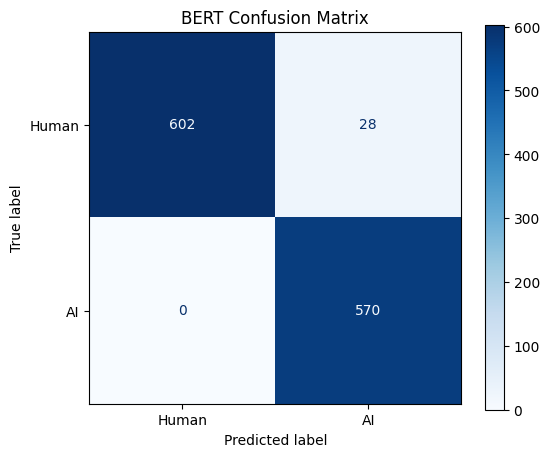

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

outputs = trainer.predict(small_eval_dataset)
y_pred = outputs.predictions.argmax(-1)
y_true = outputs.label_ids

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["Human", "AI"], ax=ax, cmap="Blues")
plt.title("BERT Confusion Matrix")
plt.show()